In [6]:
#1
# Titanic Analytics Module
# Student-style notebook with clear sections

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE
import joblib

In [7]:
#2
# Load Titanic dataset once and save offline fallback
df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)

print("Dataset shape:", df.shape)
print(df.info())
print(df.describe())

# Missing value percentages
missing_percent = df.isnull().mean() * 100
print("\nMissing Value Percentages:\n", missing_percent[missing_percent > 0])


Dataset shape: (891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
         survived      pclass         age       sibsp       parc

In [8]:
#3
# Apply threshold rule for missing values
df_clean = df.copy()
for col in df.columns:
    perc = missing_percent[col]
    if perc == 0:
        continue
    elif perc < 5:
        df_clean = df_clean.dropna(subset=[col])
    elif perc <= 30:
        if df[col].dtype == 'float64':
            df_clean[col] = df_clean[col].fillna(df[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df[col].mode()[0])
    else:
        df_clean[col] = df_clean[col].astype(str).fillna("missing")

print("\nAfter cleaning, shape:", df_clean.shape)



After cleaning, shape: (889, 15)


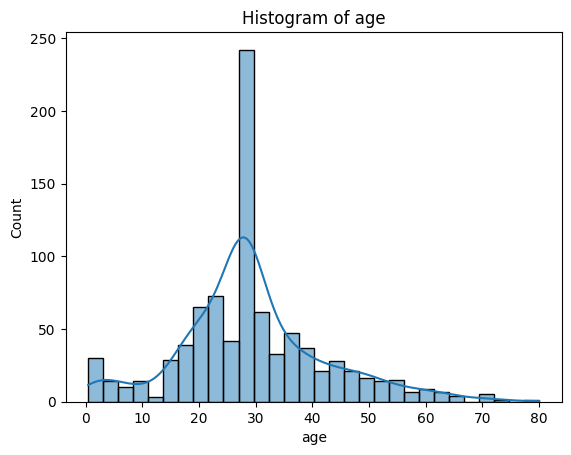

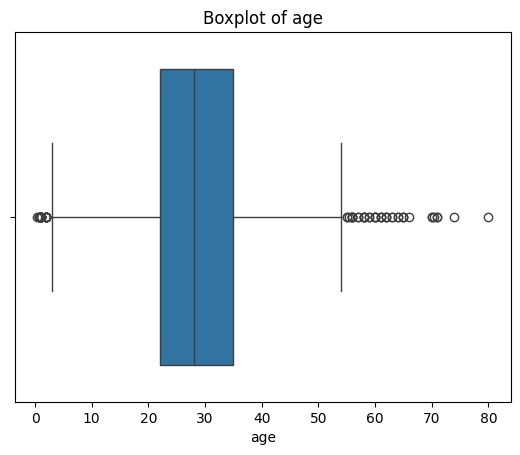

age outliers: 65


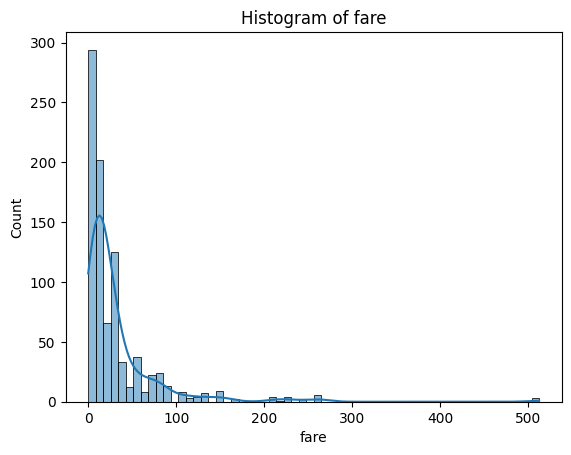

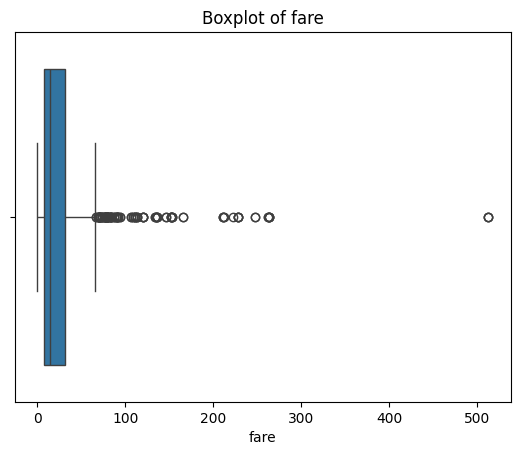

fare outliers: 114

Fare stats: 32.09668087739032 14.4542 8.05
Fare is right-skewed


In [9]:
#4
# Histograms, boxplots, outliers, skewness
for col in ['age','fare']:
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

    Q1, Q3 = df_clean[col].quantile([0.25,0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col} outliers:", outliers)

fare_mean, fare_median, fare_mode = df_clean['fare'].mean(), df_clean['fare'].median(), df_clean['fare'].mode()[0]
print("\nFare stats:", fare_mean, fare_median, fare_mode)
if fare_mean > fare_median > fare_mode:
    print("Fare is right-skewed")
elif fare_mean < fare_median < fare_mode:
    print("Fare is left-skewed")
else:
    print("Fare is symmetric")



Survival rate by sex:
 sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

Survival rate by pclass:
 pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival rate by sex+pclass:
 sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


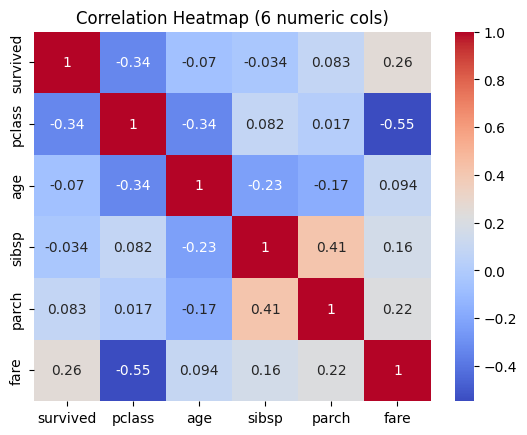


Top 2 strongest correlations:
 fare    pclass    0.548193
pclass  fare      0.548193
dtype: float64


In [ ]:
#5

print("\nSurvival rate by sex:\n", df_clean.groupby('sex')['survived'].mean())
print("\nSurvival rate by pclass:\n", df_clean.groupby('pclass')['survived'].mean())
print("\nSurvival rate by sex+pclass:\n", df_clean.groupby(['sex','pclass'])['survived'].mean())

# Correlation matrix (6 numeric columns)
num_cols = ['survived','pclass','age','sibsp','parch','fare']
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (6 numeric cols)")
plt.show()

# Absolute correlations
abs_corr = corr.abs()

for i in range(len(abs_corr)):
    abs_corr.iloc[i, i] = 0

# Rank correlations
pairs = abs_corr.unstack().sort_values(ascending=False)
print("\nTop 2 strongest correlations:\n", pairs[:2])



In [13]:
#6
X = df_clean[['pclass','sex','age','sibsp','parch','fare','embarked']]
y = df_clean['survived']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print("\nClass balance:", y.value_counts(normalize=True))

numeric_features = ['age','sibsp','parch','fare']
categorical_features = ['sex','embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])



Class balance: survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64


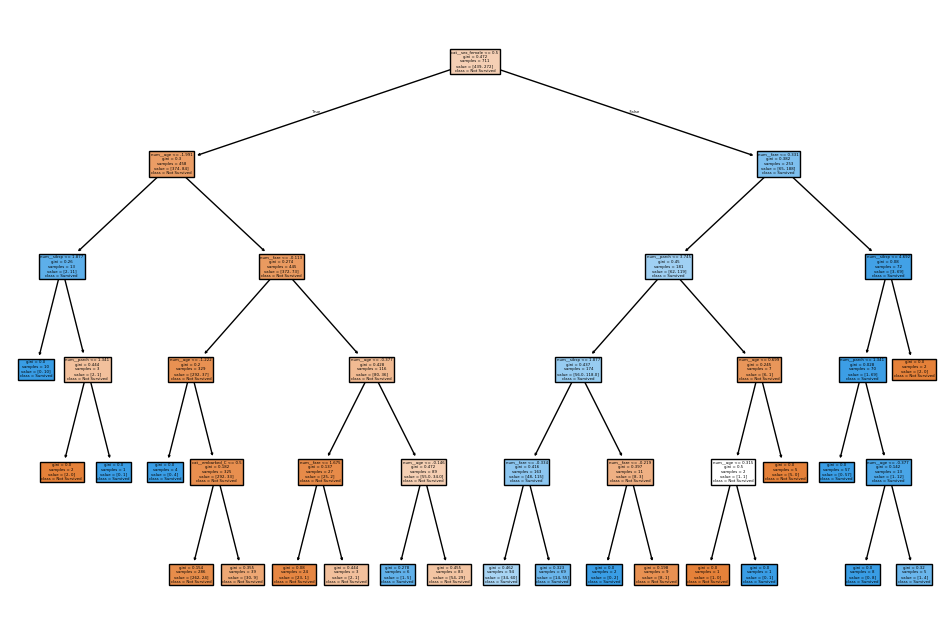

,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.780899,0.754386,0.632353,0.688000,0.826471
Decision Tree,0.808989,0.774194,0.705882,0.738462,0.812701
Random Forest,0.797753,0.775862,0.661765,0.714286,0.821123


In [14]:
#7
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
}

results = {}
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test,y_pred),
        "Recall": recall_score(y_test,y_pred),
        "F1": f1_score(y_test,y_pred),
        "AUC": roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
    }
    if name=="Decision Tree":
        plt.figure(figsize=(12,8))
        plot_tree(model, feature_names=preprocessor.get_feature_names_out(), class_names=["Not Survived","Survived"], filled=True)
        plt.show()

pd.DataFrame(results).T


In [15]:
#8
baseline = LogisticRegression(max_iter=500)
balanced = LogisticRegression(max_iter=500, class_weight='balanced')

X_train_num = preprocessor.fit_transform(X_train)
X_test_num = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_num, y_train)
smote_model = LogisticRegression(max_iter=500)

pipe_base = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', baseline)])
pipe_base.fit(X_train, y_train)
print("Baseline F1:", f1_score(y_test, pipe_base.predict(X_test)))

pipe_bal = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', balanced)])
pipe_bal.fit(X_train, y_train)
print("Balanced F1:", f1_score(y_test, pipe_bal.predict(X_test)))

smote_model.fit(X_res, y_res)
print("SMOTE F1:", f1_score(y_test, smote_model.predict(X_test_num)))


Baseline F1: 0.688
Balanced F1: 0.7272727272727273
SMOTE F1: 0.7175572519083969


In [16]:
#9
param_grid = {'classifier__n_estimators':[50,100],
              'classifier__max_depth':[5,10,None],
              'classifier__max_features':['sqrt','log2']}
rf_pipe = Pipeline(steps=[('preprocessor',preprocessor),
                          ('classifier',RandomForestClassifier(oob_score=True,random_state=42))])
grid = GridSearchCV(rf_pipe,param_grid,cv=3)
grid.fit(X_train,y_train)
print("\nBest RF params:", grid.best_params_)
print("OOB score:", grid.best_estimator_.named_steps['classifier'].oob_score_)



Best RF params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
OOB score: 0.8157524613220816


In [17]:
#10
reg = Pipeline(steps=[('preprocessor',preprocessor),
                      ('regressor',LinearRegression())])
reg.fit(X_train,y_train)
y_pred_reg = reg.predict(X_test)
mae = mean_absolute_error(y_test,y_pred_reg)
mse = mean_squared_error(y_test,y_pred_reg)
rmse = np.sqrt(mse)   # manual sqrt
r2 = r2_score(y_test,y_pred_reg)
adj_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("\nRegression metrics:", {"MAE":mae,"RMSE":rmse,"R2":r2,"AdjR2":adj_r2})



Regression metrics: {'MAE': 0.3248711010219584, 'RMSE': np.float64(0.3998693667586573), 'R2': 0.3227099794393202, 'AdjR2': 0.2948215668279981}


In [18]:
#11
best_pipeline = grid.best_estimator_
joblib.dump(best_pipeline,"titanic_pipeline.pkl")
print("\nPipeline saved as titanic_pipeline.pkl")



Pipeline saved as titanic_pipeline.pkl
